Resumen:

En este trabajo se realizó el análisis de una señal de electrocardiograma (ECG) con el objetivo de estudiar su comportamiento en el tiempo y sus propiedades estadísticas. Se partio de dos conjuntos de señales, una filtrada y una sin filtra, esto con el fin de facilitar la identificación de los latidos cardíacos para posteriormente, detectar los picos principales y se segmentar la señal en ciclos cardíacos individuales.

A partir de estos ciclos, se calcularon parámetros como el promedio, el valor RMS, la varianza y la desviación estándar, evidenciando variaciones entre los latidos. Estas diferencias fueron analizadas mediante pruebas estadísticas, donde se determinó que los datos no siguen una distribución normal y que existen diferencias significativas entre ciclos.

Adicionalmente, se evaluó la estacionariedad de la señal utilizando la prueba de Dickey-Fuller, la cual indicó ausencia de tendencia global. Sin embargo, los resultados generales muestran que la señal no es completamente estacionaria, sino que presenta variaciones locales entre ciclos.

El electrocardiograma (ECG) es una señal bioeléctrica que representa la actividad eléctrica del corazón a lo largo del tiempo. Esta señal es fundamental para el análisis del funcionamiento cardíaco, ya que permite identificar eventos fisiológicos como la despolarización y repolarización de las cavidades cardíacas.

Un ciclo típico de ECG está compuesto por las ondas P, QRS y T, donde el complejo QRS representa la despolarización ventricular y es el componente de mayor amplitud, siendo clave para la detección de latidos. Debido a su origen fisiológico, la señal ECG presenta variabilidad entre ciclos, lo que la clasifica como una señal de naturaleza aleatoria o no determinística.

El análisis de bioseñales como el ECG requiere técnicas de procesamiento digital para mejorar la calidad de la señal y extraer información relevante. Estas señales suelen estar contaminadas con ruido, como interferencias eléctricas de los equipos de adquisicion o de los equipos del medio, hasta movimientos musculares

Dado que las bioseñales presentan comportamiento aleatorio, es necesario describirlas mediante parámetros estadísticos:

* Media: valor promedio de la señal.
* Valor RMS: medida de la energía de la señal.
* Varianza: Indica que tan dispersos estan los datos con respecto a su media.
* Desviación estándar: raíz cuadrada de la varianza, indica que tanto se dispersan los datos con respecto a su media.

Para comparar ciclos cardíacos es posible emplear diversas pruebas estadísticas que permiten determinar si existen diferencias significativas entre ellos.

* Prueba de Shapiro: evalúa la normalidad de los datos.
* Prueba de Levene: verifica la igualdad de varianzas (homocedasticidad).
* Prueba t de Student: compara medias entre dos grupos bajo supuestos de normalidad.
* Prueba U de Mann-Whitney: alternativa no paramétrica cuando no se cumple normalidad.
* Prueba de Dickey-Fuller: permite determinar la presencia de tendencia en la señal. (Una señal puede no presentar tendencia global y aun así mostrar variaciones locales.)





La estacionariedad es una propiedad de las señales aleatorias que indica que sus características estadísticas (media, varianza, distribución) permanecen constantes en el tiempo.

El preprocesamiento de la señal ECG elegida permitio observar la señal de una forma mas natural eliminando offset y ruido que podria afectar en sus valores estadisticos a la hora de querer analizar estos o la estacionariedad de la señal, esto se pudo ver claramente en la comparacion de medias y varianzas donde el valor de offset ocasionaba que la media de la señal sin filtrar fuera considerablemente mas elevado que la señal filtrada cuyos valores oscilaban entre 0 y la amplitud de los picos R de la señal.
Diferenciar la señal por medio de picos R fue de gran utilidad para el entendimiento de la señal, pues al tomar como ciclos la diferencia entre 2 picos R es posible capturar toda la onda de un ciclo cardiaco, desde la onda P, complejo QRs hasta la onda T, esto permite un mejor entendimiento del comportamiento entre ciclos y como cada ciclo puede ser diferente de otro, esto debido a la misma anatomia y fisiologia cardiaca donde aumentos en la frecuencia o intensidad del latido pueden variar los componentes captados por los equipos de adquisicion.
El analisis estadistico, principalmente buscaba la determinacion de la estacionariedad o no de la señal, para lo cual se recurrio a pruebas de normalidad, desviacion estandar, y pruebas alternativas.
Una de las mas relevantes fue la prueba de Dickey-Fuller que aunque indicara que la señal es estacionaria al no presentar tendencia global (Valor p < 0.05), los análisis estadísticos entre ciclos (Prueba de shapiro, Levene, Media, Varianza, desviacion estandar) evidencian diferencias significativas en sus propiedades. Esto demuestra que la señal no es estrictamente estacionaria, sino que presenta variaciones locales entre ciclos, o en otras palabras, la señal puede ser localmente estacionaria o localmente no estacionaria, pero al evaluar el comportamiento completo de la señal (Resultado de Dicker Fuller) esta da como resultado un comportamiento estacionario.

* El filtrado de la señal ECG es una etapa fundamental que permite eliminar ruido e interferencias, mejorando la identificación de características relevantes como los complejos QRS y facilitando el análisis posterior de la señal, adicionalmente, entender el espectro de frecuencias de interes de la señal ECG puede ayudar a la lectura e interpretacion de estas pues como fue posible observar se confirmo que el espectro de interes se da entre los 0-100Hz como se reporta en la literatura.

* La correcta detección de los picos R fue fundamental para poder dividir la señal en ciclos cardíacos. Entender la importancia de estos ciclos cardiacos, es vital a la hroa de analizar un ECG, pues permite una visualizacion correcta de las ondas implicadas en unn latido lo que facilita su estudio y permite determinar anomalias o ruido con mas facilidad

* El análisis estadístico de los ciclos cardíacos evidenció diferencias significativas entre ellos, lo que indica que la señal ECG no es estrictamente estacionaria, ya que sus propiedades estadísticas varían en el tiempo, sin embargo, como fue posible observar con otro tipo de pruebas, esto no significa que la señal en su totalidad no sea estacionaria, sino que para el tipo de analisis y pruebas realizadas dio ese fue el resultado obtenido.

Bibliografia

[1] R. Narváez Sánchez y A. Jaramillo Velásquez, “Diseño e implementación de un sistema electrocardiográfico digital,” Revista Facultad de Ingeniería

In [ ]:
import numpy as np
from scipy.io import loadmat
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, levene, shapiro
from statsmodels.tsa.stattools import adfuller
from scipy.signal import find_peaks


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving signals.mat to signals.mat


In [ ]:
data = loadmat("signals.mat")

***Implemente una función que permita calcular el valor cuadrático medio (RMS) de una señal. El valor RMS se define en forma discreta con N número de muestras***

El RMS (Root Mean Square) o valor cuadrático medio es una forma de medir la energía o magnitud efectiva de una señal

In [ ]:
def calcular_rms(senal): #Esta funcion recibe una señal del archivo signals.mat, a esta señal se le aplicara la ecuacion para el RMS y retornara dicho valor

    return np.sqrt(np.mean(np.square(senal)))

In [ ]:
data.items() #Esta linea de codigo permite dar una valoracion inicial al tipo de datos con los que se esta trabajando, cuales son las keys y values del dataset a trabajar
#para un mejor entendimiento a la hora de usarlo


dict_items([('__header__', b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Apr 20 15:20:29 2015'), ('__version__', '1.0'), ('__globals__', []), ('Fs', array([[1024]], dtype=uint16)), ('ECG_asRecording', array([[3904.31689453, 3939.203125  , 3976.00683594, ..., 4366.41064453,
        4365.31103516, 4370.91796875]])), ('ECG_filtered', array([[ 8.87103896e-03,  5.62737497e+01,  8.57077127e+01, ...,
        -1.20952610e+02, -1.31734356e+02, -1.32898021e+02]])), ('EMG_filtered1', array([[ 17.65905117,  19.41391578,  18.89666666, ..., 242.49414224,
        220.4135886 , 151.5810508 ]])), ('EMG_filtered2', array([[  21.1780547 ,  -79.82418538, -133.65960989, ..., -384.58994036,
        -539.9349533 , -772.65519631]])), ('EMG_asRecording1', array([[ 908.07531738,  903.17706299,  896.62982178, ..., 1433.91882324,
        1416.109375  , 1352.75012207]])), ('EMG_asRecording2', array([[-3109.97558594, -3231.01391602, -3302.34960938, ...,
        -3791.24267578, -3924.6550293 , -4109.9443

In [ ]:
senal_ecg = data['ECG_asRecording'][0] #Esta linea de codigo esta almacenando la señal correspondiente a la llave 'ECG_asRecording'
print(senal_ecg.shape) #Esta linea de codigo nos permite determinar cual es el tamaño de dicho vector almacenado en 'ECG_asRecording'

(30720,)


In [ ]:
rms_ecg = calcular_rms(senal_ecg) #Esta linea de codigo permite llamar a la funcion creada previamente para calcular el valor RMS de la señal y pasarle la señal guardada en senal_ecg
print("RMS del ECG:", rms_ecg) #Retorna el valor RMS de la señal

RMS del ECG: 4392.9682937490725


***A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo.***

In [ ]:
Fs = data['Fs'][0][0] # El vector fs es un vector con dimensiones (1,1) por lo que se debe acceder al valor dentro de la primera posicion, por lo que se debe usar [0][0]
#Si solo se usa un [0], el resultado retornado sera un vector con el valor [1024], lo cual para trabajar dificultara el proceso ya que se debe acceder al valor
print("La frecuencia de muestreo de la señal es de:", Fs) #Retorna el valor de la Tasa de muestro de la señal

La frecuencia de muestreo de la señal es de: 1024


In [ ]:
#Para la creacion del vector tiempo es necesario conocer el tiempo final de la simulacion, para esto se usa el valor encontrado de la tasa de muestreo
Ts = 1/Fs #Se define el periodo de muestreo y se asigna a una variable
longitud = len(senal_ecg) #Se determina la longitud de la senal ecg, esto con el fin de multiplicar por el valor del periodo de muestreo para encontrar el tiempo final
tf = Ts*longitud
print('El tiempo de la señal antes del proceso de filtrado es de:',tf,'s')
t = np.arange(0,tf,Ts)

El tiempo de la señal antes del proceso de filtrado es de: 30.0 s


***Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.***

In [ ]:
senal_ecg_filt = data['ECG_filtered'][0] #Esta linea de codigo esta almacenando la señal correspondiente a la llave 'ECG_filtered' la cual corresponde a la señal filtrada
print(senal_ecg_filt.shape) #Esta linea de codigo nos permite determinar cual es el tamaño de dicho vector almacenado en 'ECG_filtered'

(30720,)


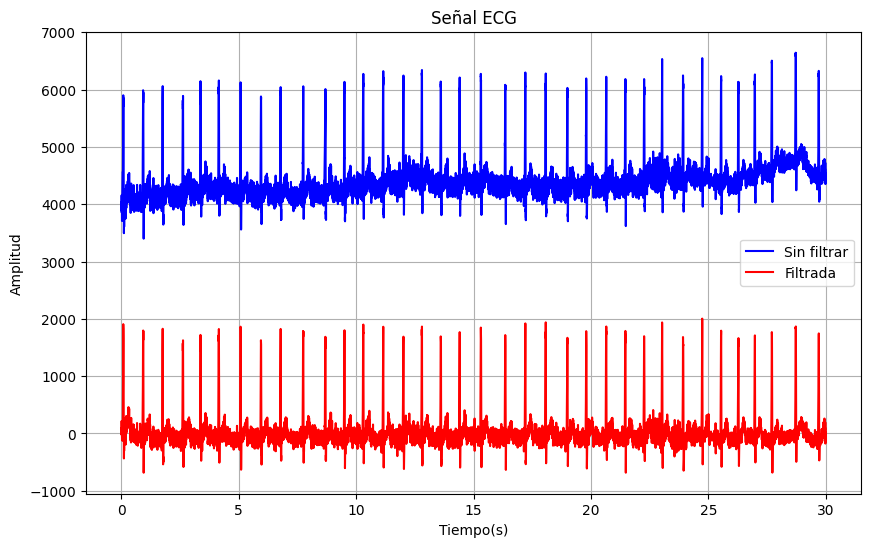

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(t,senal_ecg, color="b",label="Sin filtrar")
plt.plot(t,senal_ecg_filt,color='r',label='Filtrada')
plt.title('Señal ECG')
plt.xlabel('Tiempo(s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

In [ ]:
rms_ecg_filt = calcular_rms(senal_ecg_filt)
print('El valor RMS de la señal sin filtrar es:',rms_ecg)
print('El valor RMS de la señal filtrada es:',rms_ecg_filt)

El valor RMS de la señal sin filtrar es: 4392.9682937490725
El valor RMS de la señal filtrada es: 286.30557115249496


De la grafica es posible observar que

Señal azul (Sin filtrar): Posee un offset alto, el cual para este tipo de señales puede deberse a  los artefactos de adquisicion que se usaron para tomar las señales. contiene la información del ECG, pero está afectada por diversos tipos de ruido, de baja y alta frecuencia, el de alta frecuencia puede deberse a a movimientos musculares o interferencia electrica, y el de baja frecuencia, puede deberse a cambios en el contacto de los electrodos o incluso respiracion del paciente

Señal roja (Filtrada): Esta señal elimina el offset previamente mencionado lo que permite que la señal comience en 0 mostrando una señal con menos interferencia externa ( lo cual tambien de algun modo, elimina o reduce los ruidos de alta frecuencia ), reduce ademas los ruidos de baja frecuencia y esto permite que los picos del complejo QRS puedan ser mas claros

Debido a que existen tanto ruidos de baja, como de alta frecuencia, se espera que el filtro usado para este caso haya sido un filtro pasa bandas que conserva las frecuencias de interés del ECG.

Es posible relacionar todo esto con el valor RMS de las señales:
Lo mencionado anteriormente sobre los ruidos presentes en las señales y el friltro usado tiene un impacto directo en el cálculo del RMS,la señal sin filtrar presenta valores elevadoss debido a las interferencias por el ruido de alta y baja frecuencia, mientras que el RMS de la señal filtrada brinda informacion más precisa de la energía asociada a la actividad cardíaca, siendo más adecuado para el análisis de bioseñales.



In [ ]:
#Para hacer un analisis frecuencial se debe pasar de dominio, lo que es posible usando la transformada rapida de Fourier FFT
N = len(senal_ecg) # Esta linea de codigo permite determinar la longitud de la señal
fft_vals = np.fft.fft(senal_ecg) #Esta linea de codigo aplica la transformada rapida de Fourier
#fft_vals da como resultado un arreglo de numeros complejos el cual representara una frecuencia y la contribucion de esta en la señal.
frecuencias = np.fft.fftfreq(N, 1/Fs) #Genera las frecuencias asociadas a cada valor de la FFT, aqui se usa 1/Fs debido a que este es el periodo de muestreo porque es el tiempo entre cada muestra

In [ ]:
#Se crea una mascara para tomar solo los valores positivos, esto debido a que las frecuencias negativas lo unico que estan haciendo es repetir la informacion, por lo que no es necesario tomarlas
mask = frecuencias >= 0 #Esta linea actua como un filtro logico, el cual devuelve valores de True y False, si la frecuencia es >0 devuelve True entonces toma la frecuencia, de otro modo la omite
frecuencias = frecuencias[mask] #Se queda solo con las frecuencias positivas de la señal
fft_vals = fft_vals[mask] #Aplica la mascara al arreglo generado con la trasnformada rapida de Fourier para que tome solo los valores positivos

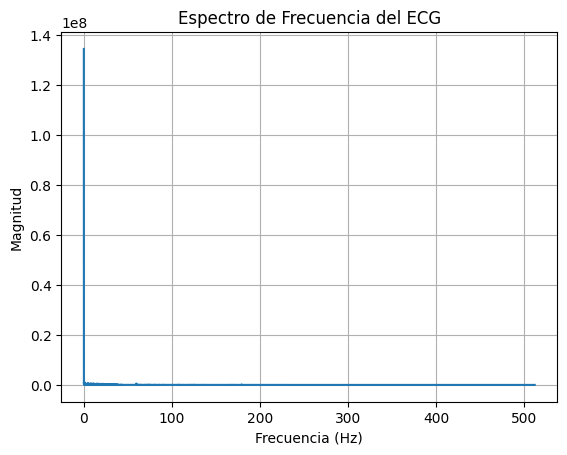

In [ ]:
plt.plot(frecuencias, np.abs(fft_vals)) #Aqui se usa el valor absoluto del arreglo resultante de la transformada rapida de Fourier, debido a que es un arreglo de numeros complejos y se necesita su magnitud
plt.title("Espectro de Frecuencia del ECG")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.grid()
plt.show()

En la grafica de espectro de frecuencias vs frecuencias es posible determinar que la mayoria de las frecuencias de interes de la señal se dan entre los 0 y 100 hz aproximadamente, que corresponde a lo encontrado en la literatura para el estudio de este tipo de señales, el estudio de R. Narváez Sánchez y A. Jaramillo Velásquez, afirma que informacion util se encuentra desde los 0,05 hasta los 100 Hz, mientras que para monitoreo clinico la informacion util se da de los 0,5 a 40 Hz [1]

***Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.***

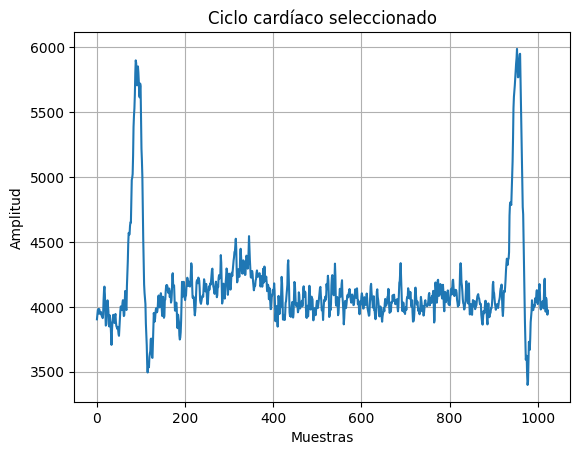

In [ ]:
ciclo = senal_ecg[0:1024]
plt.plot(ciclo)
plt.title("Ciclo cardíaco seleccionado")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid()


La selección del ciclo cardíaco se realizó en términos de muestras, considerando la frecuencia de muestreo de la señal. Posteriormente, estas muestras pueden asociarse a un intervalo de tiempo específico mediante la relación entre índice y frecuencia de muestreo.

Debido a que Fs = 1024 esto quiere decir que en 1 S hay 1024 muestras
Un ciclo cardiaco suele durar al rededor de 0,8 S, por lo que tomando las muestras correspondientes a 1 S es posible asegurar que se toma un minimo de muestras adecuado para realizar un correcto analisis del ciclo

In [ ]:
media = np.mean(ciclo) #Calcula el promedio de la señal (media = promedio)
rms_ciclo = calcular_rms(ciclo) #Calcula el valor rms con la funcion previamente definida
varianza = np.var(ciclo) #Calcula la varianza (La varianza es una medida de dispersión estadística que indica cuánto varían o se alejan los datos respecto a su media aritmética)
desviacion = np.std(ciclo) #Calcula la desviacion estandar (La desviacion estandar una medida estadística que indica cuánto se dispersan los datos con respecto al promedio media)

print("La media del ciclo cardiaco seleccionado es:", media)
print("El valor RMS del ciclo seleccionado es:", rms_ciclo)
print("La varianza del ciclo seleccionado es:", varianza)
print("La desviación estándar del ciclo seleccionado es:", desviacion)

La media del ciclo cardiaco seleccionado es: 4144.338194131851
El valor RMS del ciclo seleccionado es: 4160.468851487603
La varianza del ciclo seleccionado es: 133961.99685852733
La desviación estándar del ciclo seleccionado es: 366.0081923379958


El valor promedio de la señal (media)al ser un valor alto (>4000 para este caso )refleja la presencia de un desplazamiento de nivel en la señal, lo que corresponde al offset previamente mencionado en puntos anteriores. El valor RMS indica la energía del ciclo, la energia se ve principalmente elevada debido al complejo QRS que tiene los picos mas altos de amplitud de la señal. La varianza y la desviación estándar evidencian la variabilidad de la señal, asociada a los cambios abruptos presentes en el ciclo cardíaco, debido a que la señal posee ruido de alta y baja frecuencia es normal que estos valores se encuentren elevados, sin embargo para un mejor analisis es necesario rectificar con la señal filtrada, esto permitiria ver como cambian cada uno de estos valores luego de aplicado el filtro.

***Tome la señal filtrada. Repita el procedimiento anterior con esta señal, compare con los resultados obtenidos en el ítem anterior.***

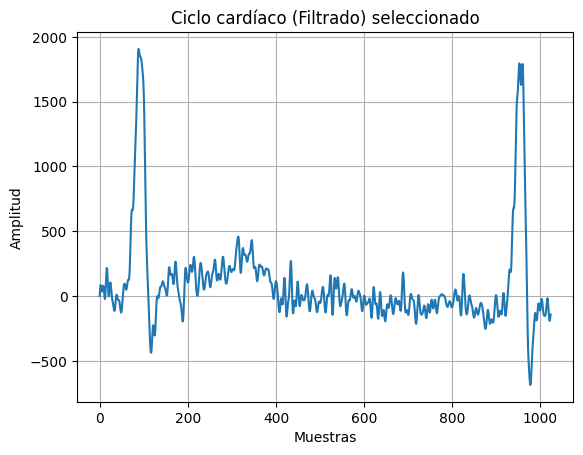

In [ ]:
ciclo_filt = senal_ecg_filt[0:1024]
plt.plot(ciclo_filt)
plt.title("Ciclo cardíaco (Filtrado) seleccionado")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid()


In [ ]:
media_filt = np.mean(ciclo_filt) #Calcula el promedio de la señal (media = promedio)
rms_ciclo_filt = calcular_rms(ciclo_filt) #Calcula el valor rms con la funcion previamente definida
varianza_filt = np.var(ciclo_filt) #Calcula la varianza (La varianza es una medida de dispersión estadística que indica cuánto varían o se alejan los datos respecto a su media aritmética)
desviacion_filt = np.std(ciclo_filt) #Calcula la desviacion estandar (La desviacion estandar una medida estadística que indica cuánto se dispersan los datos con respecto al promedio media)

print("La media del ciclo cardiaco seleccionado es:", media_filt)
print("El valor RMS del ciclo seleccionado es:", rms_ciclo_filt)
print("La varianza del ciclo seleccionado es:", varianza_filt)
print("La desviación estándar del ciclo seleccionado es:", desviacion_filt)

La media del ciclo cardiaco seleccionado es: 94.0002672623179
El valor RMS del ciclo seleccionado es: 384.78966176101744
La varianza del ciclo seleccionado es: 139227.03355277097
La desviación estándar del ciclo seleccionado es: 373.1313891282412


Una vez realizado el mismo proceso para la señal filtrada, es posible tener un
mejor entendimiento de lo dicho anteriormente, para el valor del promedio,
debido a que el filtro elimina el offset de la señal es correcto afirmar que su valor promedio debia disminuir pues ya no oscilaba en un valor de amplitud elevado sino al rededor de 0, el valor RMS por su parte, al representar la energia de la señal y verse influenciado principalmente por el compleko QRS, posee tambien una menor energia que cuando se contaba con ruido, por lo que tambien es normal que su valor disminuya, ahora bien, el valor de la varianza y la desviacion estandar aumentaron, esto puede deberse a que que la varianza representa que tanto se alejan los valores respecto a la media, en el caso de la señal sin filtrar, debido a que esta tenia valores de amplitud mas alto, es posible afirmar que habia una mayor cantidad de valores que se acercaban a la media, mientras que para el caso de la señal filtrada cuya oscilacion se da al rededor de 0, posee valores que estan mucho mas alejados de su media aritmetica, por lo que es posible afirmar que esto causa que su varianza sea mayor. Ahora bien, la desviacion estandar ( que tambien puede entenderse como la raiz cuadrada de la varianza ) representa que tan dispersos son los valores con respecto a la media, como consecuencia directa del aumento de la varianza, esto implicara que tambien se aumente la desviacion estandar debido a que al estar mas alejados los datos respecto a su media, esto implica que estan a su vez mas dispersos con respecto a la misma.

***Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?***

In [ ]:
#Se usa la funcion find_peaks de la libreria scipy.signals la cual reconoce los picos R de una señal ECG mediante un valor de umbral previamente dado y calcula la distancia minima que deberia haber entre picos R
peaks, _ = find_peaks(
    senal_ecg_filt,
    height=1400,
    distance=int(0.8 * Fs)     # distancia mínima entre latidos
)

In [ ]:
peaks = peaks[:16] #Se limita la cantidad de picos a 15 para alcanzar los 15 ciclos

In [ ]:
ciclos = [] #Se crea un vector para almacenar los ciclos

for i in range(len(peaks)-1): #Recorre los indices de la lista de picos previamente definida
    inicio = peaks[i] #Toma un valor de pico como inicio del ciclo
    fin = peaks[i+1]#Define el final del ciclo, que corresponderia al final de un latido
    ciclo_num = senal_ecg_filt[inicio:fin]#Esta linea de codigo toma el segmento previamente definido por el inicio y fin de un cilo
    ciclos.append(ciclo_num)#El segmento que corresponde a un ciclo sera almacenado en la lista de ciclos



In [ ]:
min_len = min(len(c) for c in ciclos)
ciclos = [c[:min_len] for c in ciclos]

In [ ]:
medias = [] #Se crea una lista medias para almacenar las medias de los ciclos
varianzas = [] #Se crea una lista de varianzas para almacenar las varianzas de los ciclos

for ciclo in ciclos: #La variable ciclo recorre la lista de ciclos previamente definida para definir la media y varianza de cada uno de los ciclos en la lista
    medias.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

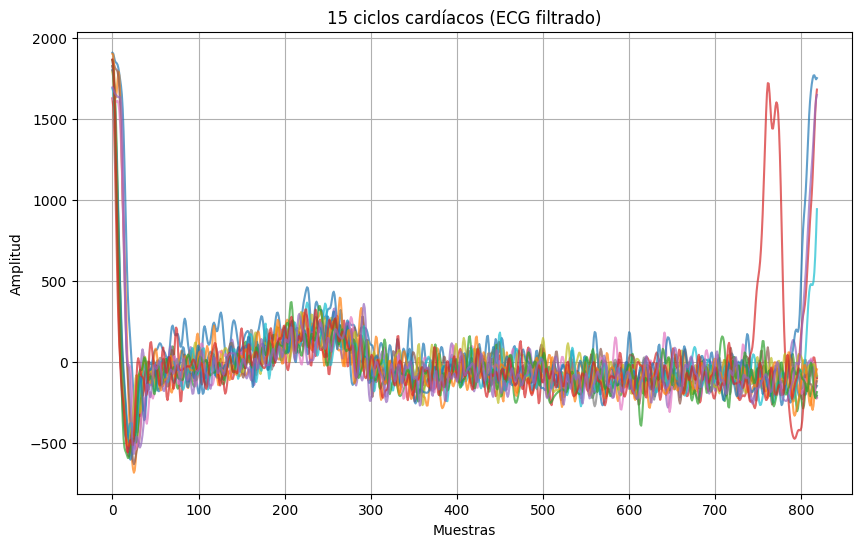

In [ ]:
plt.figure(figsize=(10,6))

for ciclo in ciclos:
    plt.plot(ciclo, alpha=0.7) #Alpha permite que las graficas de los ciclos se vean al mismo tiempo, con un alpha de 1 quedaria el color superpuesto y no permitiria ver los demas ciclos

plt.title("15 ciclos cardíacos (ECG filtrado)")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid()
plt.show()


In [ ]:
for i in range(len(medias)-1):
    print(f"Ciclo {i+1}:")
    print(f"  Media = {medias[i]}")
    print(f"  Varianza = {varianzas[i]}")
    print("-------------------------")

Ciclo 1:
  Media = 56.20575739805617
  Varianza = 76146.10469606098
-------------------------
Ciclo 2:
  Media = -33.9607714637137
  Varianza = 62033.69098692194
-------------------------
Ciclo 3:
  Media = -43.30055246472703
  Varianza = 39472.89093821748
-------------------------
Ciclo 4:
  Media = 1.936253367262948
  Varianza = 94165.83872328784
-------------------------
Ciclo 5:
  Media = -41.48445744614181
  Varianza = 35205.24224649042
-------------------------
Ciclo 6:
  Media = -13.16036893554504
  Varianza = 61023.13815633546
-------------------------
Ciclo 7:
  Media = -14.487596740367437
  Varianza = 51947.03105537633
-------------------------
Ciclo 8:
  Media = -34.024522505440935
  Varianza = 32045.409514932497
-------------------------
Ciclo 9:
  Media = -9.549658223762776
  Varianza = 33109.499774707045
-------------------------
Ciclo 10:
  Media = -33.75536664985302
  Varianza = 37217.43027761146
-------------------------
Ciclo 11:
  Media = 8.802288545764462
  Varianza

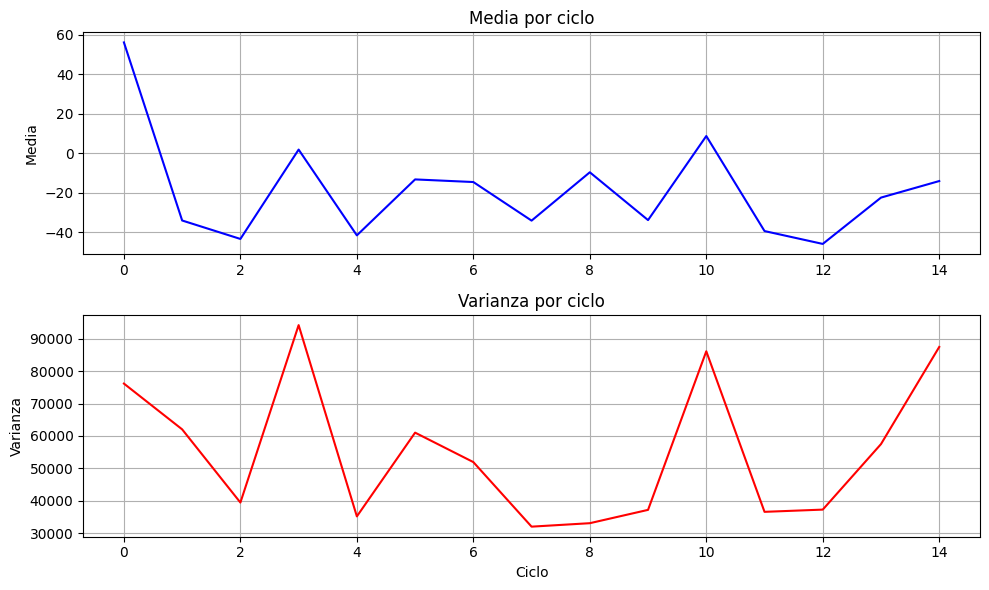

In [ ]:
plt.figure(figsize=(10,6))

# Subplot 1: Media
plt.subplot(2,1,1)  # 2 filas, 1 columna, posición 1
plt.plot(medias, 'b')
plt.title("Media por ciclo")
plt.ylabel("Media")
plt.grid()

# Subplot 2: Varianza
plt.subplot(2,1,2)  # 2 filas, 1 columna, posición 2
plt.plot(varianzas, 'r')
plt.title("Varianza por ciclo")
plt.xlabel("Ciclo")
plt.ylabel("Varianza")
plt.grid()

plt.tight_layout()
plt.show()

Una señal es estacionaria si sus propiedades estadísticas (media, varianza) no cambian en el tiempo. para este caso, la señal ECG no es estrictamente estacionaria, ya que sus propiedades estadísticas varían entre ciclos debido a la naturaleza fisiológica del corazón(El ritmo cardiaco no siempre es el mismo, este puede variar, adicionalmente puede cambiar su amplitud). Sin embargo, puede considerarse localmente estacionaria en intervalos cortos, donde las características de los ciclos son similares.

***Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (prueba U de Mann-Whitney).***

In [ ]:
ciclo1 = ciclos[0]
ciclo2 = ciclos[1]
min_len = min(len(ciclo1), len(ciclo2)) # Se debe garantizar que ambos ciclos tengan la misma longitud para poder hacer el analisis estadistico por lo que se crea una variable que obtenga esta longitud minima
ciclo1 = ciclo1[:min_len] #Se toma del ciclo 1 todos los valores hasta la longitud minima previamente definida
ciclo2 = ciclo2[:min_len] #Se toma del ciclo 2 todos los valores hasta la longitud minima previamente definida

In [ ]:
#Para la prueba de normalidad se puede usar de la libreria scipy la prueba shapiro
#Shapiro determina si un conjunto de datos proviene de una distribución normal (gaussiana)
stat1, p1 = shapiro(ciclo1)
stat2, p2 = shapiro(ciclo2)

#El valor P en una prueba shapiro determina si una muestra sigue una distribución normal
#Si el p-valor >=0,05, los datos son normales (no se rechaza la hipótesis nula). Si el p-valor < 0,05, se concluye que los datos no tienen distribución normal
#Hipótesis Nula(Ho): Los datos provienen de una población distribuida normalmente.
if p1 and p2 >= 0.05:
  print("El valor p1:", p1 ,"Tiene una distribucion normal")
  print("El valor p2:", p2 ,"Tiene una distribucion normal")
else:
  print("El valor de p1 es:",p1," ,este valor es < 0.05 por lo tanto se rechaza la normalidad. Los datos se desvían significativamente de una distribución normal")
  print("El valor de p2 es:",p2," ,este valor es < 0.05 por lo tanto se rechaza la normalidad. Los datos se desvían significativamente de una distribución normal")





El valor de p1 es: 2.835808576334731e-39  ,este valor es < 0.05 por lo tanto se rechaza la normalidad. Los datos se desvían significativamente de una distribución normal
El valor de p2 es: 6.349756576733251e-41  ,este valor es < 0.05 por lo tanto se rechaza la normalidad. Los datos se desvían significativamente de una distribución normal


In [ ]:
stat_lev, p_levene = levene(ciclo1, ciclo2)
print("El valor p con la prueba de homocedasticidad es:", p_levene)

El valor p con la prueba de homocedasticidad es: 0.01116768832019584


La prueba de Levene mide la homogeneidad de varianzas (homocedasticidad), es decir, verifica si dos o más grupos de muestras tienen varianzas iguales.

Para este caso, como el valor p es > 0,05 es posible afirmar que si existe una igualdad en las varianzas de ambos ciclos.

Aunque se cumple homocedasticidad, la falta de normalidad impide el uso adecuado de la prueba t, por lo que se recurre a una prueba no paramétrica como la prueba U de Mann-Whitney

In [ ]:
#Como no se cumple criterio de normalidad, se procede a hacer prueba U de Mann-Whitney

stat, p_mw = mannwhitneyu(ciclo1, ciclo2)
print("Mann-Whitney p-value:", p_mw)

Mann-Whitney p-value: 4.623317456164561e-30


La prueba U de Mann-Whitney mide si existen diferencias significativas entre las distribuciones de dos grupos independientes, comparando sus rangos en lugar de sus medias.
Al obtener un valor p con un valor tan bajo en la prueba es posible afirmar que los ciclos no siguen una disfribucion normal y que ademas son diferentes entre si, esto puede deberse a los aspectos fisiologicos que implica el latido cardiaco, cada latido tiene variaciones reales por lo que dificulta la normalidad entre sus datos, esto podria reforzar la idea de que la señal no es estacionaria pues ademas de la media y la varianza su distribucion no cumple los criterios de normalidad

In [ ]:
#Ahora se procede a analizar otros dos ciclos

ciclo14 = ciclos[13]
ciclo15  = ciclos[14]
min_len_2 = min(len(ciclo14), len(ciclo15)) # Se debe garantizar que ambos ciclos tengan la misma longitud para poder hacer el analisis estadistico por lo que se crea una variable que obtenga esta longitud minima
ciclo14 = ciclo14[:min_len] #Se toma del ciclo 14 todos los valores hasta la longitud minima previamente definida
ciclo15 = ciclo15[:min_len] #Se toma del ciclo 15 todos los valores hasta la longitud minima previamente definida

In [ ]:
stat14, p14 = shapiro(ciclo14)
stat15, p15 = shapiro(ciclo15)

if p14 and p15 >= 0.05:
  print("El valor p14:", p14 ,"Tiene una distribucion normal")
  print("El valor p15:", p15 ,"Tiene una distribucion normal")
else:
  print("El valor de p14 es:",p14," ,este valor es < 0.05 por lo tanto se rechaza la normalidad. Los datos se desvían significativamente de una distribución normal")
  print("El valor de p15 es:",p15," ,este valor es < 0.05 por lo tanto se rechaza la normalidad. Los datos se desvían significativamente de una distribución normal")


El valor de p14 es: 6.214745810891662e-39  ,este valor es < 0.05 por lo tanto se rechaza la normalidad. Los datos se desvían significativamente de una distribución normal
El valor de p15 es: 8.226349125690807e-41  ,este valor es < 0.05 por lo tanto se rechaza la normalidad. Los datos se desvían significativamente de una distribución normal


In [ ]:
stat_lev_2, p_levene_2 = levene(ciclo14, ciclo15)
print("El valor p con la prueba de homocedasticidad es:", p_levene_2)

El valor p con la prueba de homocedasticidad es: 0.15155886824466314


Al igual que en el primer analisis de ciclos aunque se cumple homocedasticidad, la falta de normalidad impide el uso adecuado de la prueba t, por lo que se recurre a una prueba no paramétrica como la prueba U de Mann-Whitney

In [ ]:
stat_2, p_mw_2 = mannwhitneyu(ciclo14, ciclo15)
print("Mann-Whitney p-value:", p_mw_2)

Mann-Whitney p-value: 0.3374075369997307


Nuevamente, como en los primeros dos ciclos analizados se obtuvo un valor p con un valor bajo < 0.05, por lo que es posible afirmar que los ciclos no siguen una disfribucion normal y que ademas son diferentes entre si,ademas de esto, se le puede atribuir las mismas caracteristicas fisiologicas de los ciclos anteriores a estos por lo que el resultado del valor p se debe a estas mismas caracteristicas fisiologicas de los latidos entre ciclos.

***Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal (Estacionariedad)***

In [ ]:
#La prueba de Dickey-Fuller sirve para determinar si una serie temporal es estacionaria o no, detectando la presencia de una raíz unitaria
#Detección de Raíz Unitaria: La hipótesis nula (Ho) asume que la serie no es estacionaria (tiene raíz unitaria), mientras que la hipótesis alternativa (H1) sugiere que la serie es estacionaria
#Si el p-valor es menor que el nivel de significancia (ej. 0.05), se rechaza y se confirma que la serie es estacionaria. Si no se rechaza, la serie necesita diferenciación.

result = adfuller(np.squeeze(senal_ecg_filt))
print('ADF Statistic: %f' % result[0])
print('p-value: ',result[1])

ADF Statistic: -24.134107
p-value:  0.0


El valor p = 0 de la prueba de Dickey Fuller rechaza la hipotesis nula donde dice que la señal no es estacionaria, esto sugeriria que la hipotesis correcta es la alternativa, afirmando que la señal es estacionaria al no presentar tendencia global.
